In [ ]:
import os
import glob
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm

# --- CONFIGURATION ---
ROOT_DIR = Path("/kaggle/input")
OUTPUT_DIR = Path("/kaggle/working/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- MAPPING BRAIN (V12: THE DRAGNET) ---
LABEL_MAP = {
    # === 1. INDIAN FRESHWATER (The Majors) ===
    'rohu': 'rohu', 'labeo rohita': 'rohu',
    'catla': 'catla', 'katla': 'catla',
    'mrigal': 'mrigal', 'cirrhinus': 'mrigal',
    'tilapia': 'tilapia', 'oreochromis': 'tilapia',
    'pangasius': 'pangas_catfish', # Split from generic catfish
    'catfish': 'catfish',
    
    # === 2. EXOTIC CARPS (Split for more classes) ===
    'silver carp': 'silver_carp', 
    'common carp': 'common_carp', 
    'grass carp': 'grass_carp',
    
    # === 3. INDIAN MARINE (The Money Fish) ===
    'hilsa': 'hilsa', 'ilish': 'hilsa',
    'mackerel': 'mackerel', 'bangda': 'mackerel', 'rastrelliger': 'mackerel',
    'seer': 'seer_fish', 'surmai': 'seer_fish', 'spanish mackerel': 'seer_fish',
    'barracuda': 'barracuda', 'sheela': 'barracuda',
    'sardine': 'sardine', 'mathi': 'sardine', 'tarli': 'sardine',
    'anchovy': 'anchovy', 'nethili': 'anchovy',
    
    # === 4. POMFRETS (Split) ===
    'black pomfret': 'black_pomfret', 'halwa': 'black_pomfret',
    'pomfret': 'silver_pomfret', 'paplet': 'silver_pomfret', # Default to Silver if unspecified
    
    # === 5. MARKET SPECIALS (Split) ===
    'pink perch': 'pink_perch', 'rani': 'pink_perch', 
    'red mullet': 'red_mullet', 'barbunya': 'red_mullet', # Turkish/Indian overlap
    'sea bream': 'sea_bream', 'cipura': 'sea_bream',
    'sea bass': 'sea_bass', 'levrek': 'sea_bass',
    'barramundi': 'barramundi', 'bhetki': 'barramundi', # Keep separate from Sea Bass if possible
    'trout': 'trout', 'alabalik': 'trout',
    'black sea sprat': 'sprat', # New Class!
    
    # === 6. CRUSTACEANS & MOLLUSKS ===
    'prawn': 'prawn', 'shrimp': 'prawn', 
    'crab': 'crab', 'mud_crab': 'crab',
    'squid': 'squid', 'cuttlefish': 'squid', # New Class!
    
    # === 7. STATUS ===
    'healthy': 'healthy',
    'white_spot': 'white_spot_virus', 'wssv': 'white_spot_virus',
    'black_gill': 'black_gill_disease', 'bg': 'black_gill_disease',
    'fresh_eyes': 'fresh_eye', 'fresh_gills': 'fresh_gill',
    'nonfresh_eyes': 'stale_eye', 'nonfresh_gills': 'stale_gill'
}

metadata = []

# SEARCH LIST (Aggressive)
SCAN_TARGETS = [
    ("fishnet", "wild_background"), 
    ("bangaladeshi", "species_market"),
    ("indian", "species_market_indian"), # Hunts for 'Indian Seafood'
    ("large-scale", "species_market_turkish"), # Hunts for 'Large Scale Fish'
    ("fish-classification", "freshness_quality"),
    ("shrimp", "shrimp_disease"),
    ("crab", "crab_dataset"),
    ("aquarium", "aquarium_background") # Use aquarium data for more variety if needed
]

print("🚀 Starting Hunter-Seeker V12 (The Dragnet)...")

processed_paths = set()

for dataset_keyword, source_tag in SCAN_TARGETS:
    # Find Roots
    found_roots = list(ROOT_DIR.glob(f"**/*{dataset_keyword}*"))
    
    for search_root in found_roots:
        if str(search_root) in processed_paths: continue
        processed_paths.add(str(search_root))
        
        print(f"🔎 Scanning: {search_root.name}...")
        
        valid_exts = {'.jpg', '.jpeg', '.png', '.bmp'}
        all_files = [p for p in search_root.rglob("*") if p.suffix.lower() in valid_exts]
        
        count = 0
        for img_path in tqdm(all_files, desc=search_root.name[:15], leave=False):
            folder = img_path.parent.name.lower()
            
            row = {
                'path': str(img_path),
                'type': 'unknown', 'label': 'unknown',
                'species_label': 'unknown', 'disease_label': 'unknown', 'freshness_score': -1.0
            }
            
            # 1. PRAWNS (Dual)
            if "shrimp" in source_tag or "prawn" in folder:
                row['type'] = 'dual'
                row['species_label'] = 'prawn'
                d_label = 'healthy'
                if 'white_spot' in folder or 'wssv' in folder: d_label = 'white_spot_virus'
                elif 'black_gill' in folder or 'bg' in folder: d_label = 'black_gill_disease'
                row['disease_label'] = d_label
                row['label'] = d_label

            # 2. FRESHNESS
            elif "freshness" in source_tag:
                row['type'] = 'freshness'
                row['species_label'] = 'unknown'
                if 'fresh' in folder and 'non' not in folder: row['freshness_score'] = 1.0
                elif 'stale' in folder or 'non' in folder: row['freshness_score'] = 0.0
                else: continue
                row['label'] = 'freshness_sample'

            # 3. SPECIES (The Expanded Roster)
            else:
                matched = False
                for k, v in LABEL_MAP.items():
                    if k in folder:
                        row['type'] = 'species'
                        row['species_label'] = v
                        row['label'] = v
                        matched = True
                        break
                
                # Fallback for Wild Background
                if not matched and ("wild" in source_tag or "fishnet" in str(search_root).lower()):
                    if count > 2000: continue # Cap background lower to let others shine
                    row['type'] = 'species'
                    row['species_label'] = 'wild_fish_background'
                    row['label'] = 'wild_fish_background'
                    matched = True
                
                if not matched: continue

            metadata.append(row)
            count += 1
            
        print(f"   ✅ Captured {count} images.")

if metadata:
    df = pd.DataFrame(metadata)
    df.to_csv(OUTPUT_DIR / "metadata_kaggle_fused.csv", index=False)
    print("\n🏆 FUSION COMPLETE.")
    print("--- EXPANDED ROSTER ---")
    real_fish = df[~df['species_label'].isin(['unknown', 'wild_fish_background'])]
    print(real_fish['species_label'].value_counts().head(50))
else:
    print("❌ No images found.")

In [ ]:
import os
from pathlib import Path

# CONFIG
ROOT_DIR = Path("/kaggle/input")

print("🕵️ Deep Scanning FishNet for Indian Varieties...")

# 1. Find FishNet
fishnet_roots = list(ROOT_DIR.glob("**/*fishnet*"))
if not fishnet_roots:
    print("❌ FishNet not found!")
else:
    search_root = fishnet_roots[0]
    all_folders = [p.name.lower() for p in search_root.rglob("*") if p.is_dir()]
    
    print(f"📂 Scanned {len(all_folders)} folders.")

    # 2. THE LATIN HIT-LIST
    # We search for the scientific families of the missing Indian fish
    targets = {
        'Seer Fish (Vanjaram)': ['scomberomorus', 'cybium'],
        'Snakehead (Viral)': ['channa', 'channidae', 'ophicephalus'],
        'Sardine (Mathi)': ['sardinella', 'sardina', 'pilchardus'],
        'Anchovy (Nethili)': ['stolephorus', 'engraulis', 'encrasicholus'],
        'Barramundi (Bhetki)': ['lates', 'calcarifer'],
        'Needlefish': ['belonidae', 'strongylura'],
        'Catfish': ['mystus', 'wallago', 'pangasius']
    }
    
    print("\n--- SEARCH RESULTS ---")
    for common_name, latin_names in targets.items():
        found = []
        for lat in latin_names:
            # Fuzzy match: is the latin name inside any folder name?
            matches = [f for f in all_folders if lat in f]
            if matches: found.extend(matches)
            
        if found:
            print(f"✅ FOUND {common_name}: {list(set(found))[:3]}") # Show top 3 matches
        else:
            print(f"❌ MISSING {common_name}")

In [ ]:
# 1. INSTALL VINTAGE TF
!pip uninstall -y tensorflow
!pip install "numpy<1.24" "protobuf==3.20.3" "tensorflow==2.12.0" --force-reinstall
print("✅ Downgraded. PLEASE RESTART SESSION NOW.")

In [ ]:
import os
import cv2
import hashlib
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
from sklearn.model_selection import StratifiedGroupKFold

# --- CONFIGURATION ---
INPUT_CSV = Path("/kaggle/working/processed/metadata_kaggle_fused.csv")
OUTPUT_IMG_DIR = Path("/kaggle/working/processed/images_224")
OUTPUT_IMG_DIR.mkdir(parents=True, exist_ok=True)
IMG_SIZE = 224

# --- ENGINE ---
def compute_md5(img_array):
    return hashlib.md5(img_array.tobytes()).hexdigest()

if not INPUT_CSV.exists():
    print("⚠️ HALT: Run Notebook 01 first!")
else:
    df = pd.read_csv(INPUT_CSV)
    valid_records = []
    
    print(f"⚡ Processing {len(df)} images with integrity check...")
    
    # Iterate with Progress Bar
    for idx, row in tqdm(df.iterrows(), total=len(df)):
        try:
            img_path = row['path']
            # --- � INTEGRITY CHECK � ---
            # 1. Read Image
            img = cv2.imread(img_path)
            
            # 2. Check if read failed or image is empty
            if img is None or img.size == 0:
                print(f"⚠️ Skipping corrupt or missing file: {img_path}")
                continue 

            # 3. Resize and Hash (Standard Procedure)
            img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            content_hash = compute_md5(img_resized)
            
            # 4. Save Clean Copy
            new_filename = f"{content_hash}.jpg"
            new_path = OUTPUT_IMG_DIR / new_filename
            
            if not new_path.exists():
                cv2.imwrite(str(new_path), img_resized)
            
            # 5. Update Record
            record = row.to_dict()
            record['new_path'] = str(new_path)
            record['content_hash'] = content_hash
            record['stratify_group'] = f"{row['type']}_{row.get('species_label', 'unknown')}" 
            valid_records.append(record)
            
        except Exception as e:
            print(f"❌ Exception on file {row.get('path', 'unknown')}: {e}")
            pass

    # --- DEDUPLICATION LOGIC ---
    clean_df = pd.DataFrame(valid_records)
    initial_count = len(clean_df)
    
    # Drop Exact Duplicates & Reset Index (Crucial Fixes)
    clean_df = clean_df.drop_duplicates(subset=['content_hash']).reset_index(drop=True)
    
    final_count = len(clean_df)
    print(f"\n� Nuked {initial_count - final_count} duplicates.")
    print(f"✅ Final Unique Dataset: {final_count} images.")

    # --- THE LEAK-PROOF SPLIT ---
    print("✂️ Performing Stratified Group Split...")
    sgkf = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)
    
    clean_df['fold'] = -1
    for fold, (train_idx, val_idx) in enumerate(sgkf.split(clean_df, clean_df['stratify_group'], clean_df['content_hash'])):
        clean_df.loc[val_idx, 'fold'] = fold
    
    # Export
    train_df = clean_df[clean_df['fold'] != 0].copy()
    val_df = clean_df[clean_df['fold'] == 0].copy()
    
    train_df.to_csv("/kaggle/working/processed/train_final.csv", index=False)
    val_df.to_csv("/kaggle/working/processed/val_final.csv", index=False)
    
    print("\n� SPLIT REPORT:")
    print(f"Train Set: {len(train_df)} images")
    print(f"Val Set:   {len(val_df)} images")
    print("Ready for Training.")

In [1]:
import pandas as pd
import tensorflow as tf
import os
from tqdm.notebook import tqdm
from pathlib import Path

# --- CONFIGURATION ---
TRAIN_CSV = Path("/kaggle/working/processed/train_final.csv")
VAL_CSV = Path("/kaggle/working/processed/val_final.csv")

def sanitize_dataset(csv_path):
    print(f"� Scanning {csv_path} for 'Poison' images...")
    
    if not csv_path.exists():
        print(f"⚠️ File not found: {csv_path}")
        return

    df = pd.read_csv(csv_path)
    initial_count = len(df)
    valid_indices = []
    
    # Scan every file
    for idx, row in tqdm(df.iterrows(), total=len(df)):
        path = row['new_path']
        try:
            # 1. Check File Existence
            if not os.path.exists(path):
                continue
                
            # 2. Check File Size
            if os.path.getsize(path) == 0:
                print(f"❌ Found Empty File: {path}")
                continue
                
            # 3. Try Decode (The Ultimate Test)
            # We read only the header to be fast, or full decode to be sure.
            # Full decode is safer for "jpeg::Uncompress failed" errors.
            img_bytes = tf.io.read_file(path)
            # expand_animations=False is faster and ignores GIF frames
            img = tf.io.decode_image(img_bytes, expand_animations=False) 
            
            # Force shape check (triggers the decode)
            if img.shape is None or img.shape[0] == 0:
                print(f"❌ Found Corrupt Image: {path}")
                continue
                
            valid_indices.append(idx)
            
        except Exception as e:
            print(f"❌ Found Bad File: {path} ({e})")

    # Save Clean Version
    clean_df = df.loc[valid_indices]
    removed_count = initial_count - len(clean_df)
    
    if removed_count > 0:
        print(f"✅ REMOVED {removed_count} bad images.")
        # Overwrite the file so the next cell picks up the clean data
        clean_df.to_csv(csv_path, index=False)
    else:
        print("✅ Dataset is Clean.")

# EXECUTE
sanitize_dataset(TRAIN_CSV)
sanitize_dataset(VAL_CSV)

KeyboardInterrupt: 

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
import pandas as pd
import numpy as np
from pathlib import Path
import os

# ==========================================
# 1. HARDWARE INITIALIZATION
# ==========================================
print("� INITIALIZING HARDWARE...")
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.TPUStrategy(tpu)
    print(f"✅ TPU DETECTED! Cores: {strategy.num_replicas_in_sync}")
    BATCH_SIZE = 16 * strategy.num_replicas_in_sync 
except ValueError:
    print("⚠️ TPU Not Found. Checking for GPU...")
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        strategy = tf.distribute.MirroredStrategy()
        print(f"✅ GPU DETECTED: {len(gpus)} device(s).")
        BATCH_SIZE = 32
    else:
        strategy = tf.distribute.get_strategy()
        print("� NO ACCELERATOR. Running on CPU.")
        BATCH_SIZE = 32

# ==========================================
# 2. CONFIGURATION
# ==========================================
IMG_SIZE = 224
TRAIN_CSV = Path("/kaggle/working/processed/train_final.csv")
VAL_CSV = Path("/kaggle/working/processed/val_final.csv")

SPECIES_CLASSES = [
  'catfish', 'catla', 'common_carp', 'crab', 'grass_carp', 
  'mackerel', 'mrigal', 'pink_perch', 'prawn', 'red_mullet', 
  'rohu', 'sea_bass', 'sea_bream', 'silver_carp', 'sprat', 
  'tilapia', 'trout', 'wild_fish_background'
]

DISEASE_CLASSES = ['black_gill_disease', 'healthy', 'white_spot_virus']

# ==========================================
# 3. DATA PIPELINE (Still Robust, just no Fine-Tuning)
# ==========================================
def load_and_augment(path, label, is_train=True):
    # Load
    file_bytes = tf.io.read_file(path)
    img = tf.io.decode_image(file_bytes, channels=3, expand_animations=False)
    img.set_shape([None, None, 3]) 
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    
    if is_train:
        # We keep some augmentation so it doesn't overfit instantly
        if tf.random.uniform(()) > 0.75:
            img = tf.image.rot90(img, k=tf.random.uniform([], minval=0, maxval=4, dtype=tf.int32))
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, 0.2)
        img = tf.image.random_contrast(img, 0.8, 1.2)
        
        # Add light noise to prevent memorization
        noise = tf.random.normal(shape=tf.shape(img), mean=0.0, stddev=0.05)
        img = img + noise
        img = tf.clip_by_value(img, 0.0, 1.0)
        
    return img, label

def create_dataset(df, target_col, classes, is_train=True):
    df_filtered = df[df[target_col].isin(classes)].copy()
    
    # Balancing
    if is_train:
        counts = df_filtered[target_col].value_counts()
        target_count = counts.max()
        frames = [df_filtered]
        for cls in classes:
            cls_count = counts.get(cls, 0)
            if cls_count < target_count // 3:
                frames.append(df_filtered[df_filtered[target_col] == cls])
        df_filtered = pd.concat(frames).sample(frac=1.0)
        
    from sklearn.preprocessing import LabelEncoder
    encoder = LabelEncoder().fit(classes)
    labels = encoder.transform(df_filtered[target_col].values)
    paths = df_filtered['new_path'].values
    
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(lambda p, l: load_and_augment(p, l, is_train), num_parallel_calls=tf.data.AUTOTUNE)
    
    if is_train: ds = ds.shuffle(2048)
    return ds.batch(BATCH_SIZE, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

# ==========================================
# 4. MODEL BUILDER
# ==========================================
def build_clean_model(num_classes):
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    base = tf.keras.applications.MobileNetV2(
        input_tensor=inputs,
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False, 
        weights='imagenet'
    )
    base.trainable = False # � LOCKED FOREVER
    
    x = layers.GlobalAveragePooling2D()(base.output)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, out)

# ==========================================
# 5. TRAINING LOOP (Phase 1 Only)
# ==========================================
def train_and_export(task_name, classes):
    print(f"\n� STARTING TASK: {task_name.upper()}")
    
    df_train = pd.read_csv(TRAIN_CSV)
    df_val = pd.read_csv(VAL_CSV)
    
    train_ds = create_dataset(df_train, f'{task_name}_label', classes, True)
    val_ds = create_dataset(df_val, f'{task_name}_label', classes, False)
    
    with strategy.scope():
        model = build_clean_model(len(classes))
        model.compile(
            optimizer=optimizers.Adam(1e-3),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
    
    # Train for 15 epochs (Frozen only)
    print("� Training Frozen Base (No Fine-Tuning)...")
    model.fit(train_ds, validation_data=val_ds, epochs=15)
    
    # Save immediately
    save_filename = f"fish_{task_name}.weights.h5"
    model.save_weights(save_filename)
    print(f"✅ SAVED: {save_filename}")

# Run
train_and_export("species", SPECIES_CLASSES)
train_and_export("disease", DISEASE_CLASSES)

/usr/local/lib/python3.12/site-packages/jax/_src/cloud_tpu_init.py:93: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


� INITIALIZING HARDWARE...
⚠️ TPU Not Found. Checking for GPU...
� NO ACCELERATOR. Running on CPU.

� STARTING TASK: SPECIES


2025-11-28 05:49:59.445590: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
� Training Frozen Base (No Fine-Tuning)...
Epoch 1/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 169s 185ms/step - accuracy: 0.8430 - loss: 0.4983 - val_accuracy: 0.9048 - val_loss: 0.2821
Epoch 2/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 167s 186ms/step - accuracy: 0.9196 - loss: 0.2374 - val_accuracy: 0.9231 - val_loss: 0.2240
Epoch 3/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 168s 186ms/step - accuracy: 0.9326 - loss: 0.1938 - val_accuracy: 0.9224 - val_loss: 0.2116
Epoch 4/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 168s 187ms/step - accuracy: 0.9429 - loss: 0.1674 - val_accuracy: 0.9213 - val_loss: 0.2223
Epoch 5/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 170s 189ms/step - accuracy: 0.9465 - loss: 0.1518 - val_accuracy: 0.9386 - val_loss: 0.1807
Epoch 6/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 172s 191ms/step - accuracy: 0.9501 - loss: 0.1420 - val_accuracy: 0.9307 - val_loss: 0.1884
Epoch 7/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 170s 189ms/step - accuracy: 0.9526 - loss: 0.1354 - val_accuracy: 0.9429 - v

In [3]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from pathlib import Path

# ==========================================
# ⚙️ CONFIG & SETUP
# ==========================================
IMG_SIZE = 224
# Path to your CSVs from the training step
TRAIN_CSV = Path("/kaggle/working/processed/train_final.csv")
VAL_CSV = Path("/kaggle/working/processed/val_final.csv")

print(f"� TF Version: {tf.__version__}")
print("�️ Mode: Generating Browser-Safe Goldilocks Models (Int8 Math / Float IO)")

# ==========================================
# 1. ROBUST CALIBRATION GENERATOR
# ==========================================
def get_calibration_data(csv_path, sample_limit=200):
    """
    Reads image paths from your CSV to create a representative dataset.
    Returns a generator that yields [1, 224, 224, 3] Float32 tensors.
    """
    if not csv_path.exists():
        print(f"⚠️ Warning: {csv_path} not found. Falling back to directory walk.")
        return None

    df = pd.read_csv(csv_path)
    # Filter for valid images
    valid_paths = [p for p in df['new_path'].values if str(p).lower().endswith(('.jpg', '.png', '.jpeg'))]
    
    # Shuffle and pick samples
    np.random.shuffle(valid_paths)
    selected_paths = valid_paths[:sample_limit]
    
    print(f"   � calibration: selected {len(selected_paths)} images from CSV.")

    for path in selected_paths:
        try:
            img = tf.io.read_file(path)
            img = tf.io.decode_image(img, channels=3, expand_animations=False)
            img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
            img = tf.cast(img, tf.float32) / 255.0
            # Yield as list of inputs (standard TFLite format)
            yield [img.numpy()[np.newaxis, ...]]
        except Exception:
            continue

# ==========================================
# 2. ARCHITECTURE REBUILDER
# ==========================================
def build_clean_model(num_classes):
    """
    Must match your training architecture EXACTLY.
    """
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    
    # Flat MobileNetV2 (Not nested)
    base = tf.keras.applications.MobileNetV2(
        input_tensor=inputs,
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False, 
        weights=None # We load specific weights later
    )
    
    x = layers.GlobalAveragePooling2D()(base.output)
    out = layers.Dense(num_classes, activation='softmax')(x)
    
    return models.Model(inputs, out)

# ==========================================
# 3. THE CONVERTER + VERIFIER
# ==========================================
def convert_and_verify(task_name, num_classes):
    print(f"\n� PROCESSING TASK: {task_name.upper()}")
    
    # --- A. Locate Weights ---
    # Check all possible naming variations you might have created
    candidates = [
        f"fish_{task_name}.weights.h5",
        f"fish_{task_name}_clean.weights.h5",
        f"fish_{task_name}_weights.h5"
    ]
    weights_path = next((f for f in candidates if os.path.exists(f)), None)
    
    if not weights_path:
        print(f"❌ ERROR: Weights file not found for {task_name}! Checked: {candidates}")
        return
    print(f"   � Weights found: {weights_path}")

    # --- B. Rebuild & Load ---
    keras_model = build_clean_model(num_classes)
    keras_model.load_weights(weights_path)

    # --- C. Configure Goldilocks Conversion ---
    converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    
    # Use the CSV-based generator
    converter.representative_dataset = lambda: get_calibration_data(TRAIN_CSV)
    
    # � THE GOLDILOCKS CONFIG �
    # Allows Int8 for speed, but allows Builtin Float ops for the IO wrappers.
    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS_INT8,
        tf.lite.OpsSet.TFLITE_BUILTINS 
    ]
    
    # Keep React Happy
    converter.inference_input_type = tf.float32
    converter.inference_output_type = tf.float32
    
    # --- D. Convert & Save ---
    try:
        tflite_model = converter.convert()
        out_name = f"fish_{task_name}_model.tflite"
        with open(out_name, 'wb') as f:
            f.write(tflite_model)
        print(f"   � SAVED: {out_name} ({len(tflite_model)/1024:.0f} KB)")
    except Exception as e:
        print(f"   ❌ CONVERSION FAILED: {e}")
        return

    # --- E. Verification (Keras vs TFLite) ---
    print("   � Verifying Accuracy (Keras vs TFLite)...")
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()
    
    input_idx = interpreter.get_input_details()[0]['index']
    output_idx = interpreter.get_output_details()[0]['index']
    
    # Verify Input Dtype
    in_dtype = interpreter.get_input_details()[0]['dtype']
    if in_dtype != np.float32:
        print(f"      ⚠️ WARNING: Model input is {in_dtype}, expected float32!")
    else:
        print("      ✅ Input is Float32 (React Safe)")

    # Run a real image test
    gen = get_calibration_data(TRAIN_CSV, sample_limit=1)
    test_img = next(gen)[0] # Grab one image [1, 224, 224, 3]
    
    # 1. Keras Prediction
    keras_pred = keras_model.predict(test_img, verbose=0)[0]
    keras_label = np.argmax(keras_pred)
    
    # 2. TFLite Prediction
    interpreter.set_tensor(input_idx, test_img)
    interpreter.invoke()
    tflite_pred = interpreter.get_tensor(output_idx)[0]
    tflite_label = np.argmax(tflite_pred)
    
    print(f"      Keras Pred:  Class {keras_label} ({keras_pred[keras_label]:.2f})")
    print(f"      TFLite Pred: Class {tflite_label} ({tflite_pred[tflite_label]:.2f})")
    
    if keras_label == tflite_label:
        print("      ✅ PREDICTIONS MATCH!")
    else:
        print("      ⚠️ MISMATCH! (Common with Int8 quantization, verify if acceptable)")

# ==========================================
# 4. EXECUTE
# ==========================================
# Species (18 Classes)
convert_and_verify("species", 18)

print("-" * 30)

# Disease (3 Classes)
convert_and_verify("disease", 3)

� TF Version: 2.20.0
�️ Mode: Generating Browser-Safe Goldilocks Models (Int8 Math / Float IO)

� PROCESSING TASK: SPECIES
   � Weights found: fish_species.weights.h5
INFO:tensorflow:Assets written to: /tmp/tmpvtrgpj97/assets


INFO:tensorflow:Assets written to: /tmp/tmpvtrgpj97/assets


Saved artifact at '/tmp/tmpvtrgpj97'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_312')
Output Type:
  TensorSpec(shape=(None, 18), dtype=tf.float32, name=None)
Captures:
  133434650826256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133434650826832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133434650828560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133434650827600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133434650827408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133434650825872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133434650826640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133434650827216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133434650823184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133434650828752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133434650

/usr/local/lib/python3.12/site-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1764311819.814809     164 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1764311819.814837     164 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1764311819.897442     164 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


   � calibration: selected 200 images from CSV.


...

Saved artifact at '/tmp/tmp3z0a1_3f'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_468')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  133431954404368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133431954405520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133431954405328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133431954404944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133431954406096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133431954404560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133431954405712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133431954405904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133431954404176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133431954407056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1334319544

/usr/local/lib/python3.12/site-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1764311837.474204     164 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1764311837.474226     164 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


   � calibration: selected 200 images from CSV.


fully_quantize: 0, inference_type: 6, input_inference_type: FLOAT32, output_inference_type: FLOAT32
/usr/local/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


   � SAVED: fish_disease_model.tflite (2645 KB)
   � Verifying Accuracy (Keras vs TFLite)...
      ✅ Input is Float32 (React Safe)
   � calibration: selected 1 images from CSV.
      Keras Pred:  Class 0 (0.65)
      TFLite Pred: Class 2 (0.73)
      ⚠️ MISMATCH! (Common with Int8 quantization, verify if acceptable)


In [5]:
# Run this in a new cell to Stress Test the Disease Model
import numpy as np
import tensorflow as tf

def stress_test_disease(tflite_path, num_samples=20):
    print(f"⚡ STRESS TESTING: {tflite_path}")
    
    # Load Interpreter
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()
    input_idx = interpreter.get_input_details()[0]['index']
    output_idx = interpreter.get_output_details()[0]['index']
    
    # Get Generator
    gen = get_calibration_data(TRAIN_CSV, sample_limit=num_samples)
    
    matches = 0
    total = 0
    
    for inputs in gen:
        test_img = inputs[0] # [1, 224, 224, 3]
        
        # 1. Keras Pred (Ground Truth for this test)
        keras_pred = keras_model.predict(test_img, verbose=0)[0]
        k_class = np.argmax(keras_pred)
        k_conf = keras_pred[k_class]
        
        # 2. TFLite Pred
        interpreter.set_tensor(input_idx, test_img)
        interpreter.invoke()
        tflite_pred = interpreter.get_tensor(output_idx)[0]
        t_class = np.argmax(tflite_pred)
        t_conf = tflite_pred[t_class]
        
        total += 1
        if k_class == t_class:
            matches += 1
            print(f"   ✅ Match: Class {k_class} (Conf: {k_conf:.2f} vs {t_conf:.2f})")
        else:
            print(f"   ❌ Miss : Keras {k_class}({k_conf:.2f}) != TFLite {t_class}({t_conf:.2f})")
            
    print("-" * 30)
    print(f"� SCORE: {matches}/{total} ({matches/total*100:.1f}%)")

# Re-load the Keras model first to compare against
keras_model = build_clean_model(3)
keras_model.load_weights("fish_disease.weights.h5")

# Run Test
stress_test_disease("fish_disease_model.tflite")

⚡ STRESS TESTING: fish_disease_model.tflite
   � calibration: selected 20 images from CSV.


/usr/local/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


   ❌ Miss : Keras 1(0.81) != TFLite 0(0.51)
   ✅ Match: Class 0 (Conf: 0.60 vs 0.54)
   ✅ Match: Class 0 (Conf: 0.75 vs 0.75)
   ✅ Match: Class 1 (Conf: 0.86 vs 0.95)
   ✅ Match: Class 2 (Conf: 0.62 vs 0.84)
   ✅ Match: Class 0 (Conf: 0.81 vs 0.75)
   ✅ Match: Class 2 (Conf: 0.84 vs 0.90)
   ✅ Match: Class 0 (Conf: 0.81 vs 0.81)
   ✅ Match: Class 1 (Conf: 0.42 vs 0.55)
   ✅ Match: Class 0 (Conf: 0.58 vs 0.54)
   ✅ Match: Class 1 (Conf: 0.72 vs 0.66)
   ✅ Match: Class 0 (Conf: 0.80 vs 0.69)
   ✅ Match: Class 0 (Conf: 0.62 vs 0.67)
   ❌ Miss : Keras 2(0.49) != TFLite 1(0.67)
   ❌ Miss : Keras 1(0.68) != TFLite 2(0.71)
   ✅ Match: Class 1 (Conf: 0.60 vs 0.66)
   ✅ Match: Class 1 (Conf: 0.91 vs 0.83)
   ❌ Miss : Keras 2(0.85) != TFLite 0(0.60)
   ✅ Match: Class 0 (Conf: 0.68 vs 0.68)
   ✅ Match: Class 1 (Conf: 0.97 vs 0.96)
------------------------------
� SCORE: 16/20 (80.0%)



� GENERATING REPORT: SPECIES
✅ Loaded: fish_species.weights.h5
   Running predictions...
88/88 ━━━━━━━━━━━━━━━━━━━━ 16s 176ms/step

                      precision    recall  f1-score   support

             catfish       0.96      1.00      0.98        52
               catla       0.89      0.98      0.93        51
         common_carp       0.96      0.81      0.88        57
                crab       1.00      0.97      0.98        31
          grass_carp       0.63      0.83      0.72        29
            mackerel       1.00      1.00      1.00       208
              mrigal       0.97      0.84      0.90        37
          pink_perch       0.91      0.80      0.85       272
               prawn       1.00      1.00      1.00       516
          red_mullet       0.99      0.89      0.94       390
                rohu       0.87      0.81      0.84        84
            sea_bass       0.94      0.95      0.95       190
           sea_bream       0.99      0.99      0.99       19

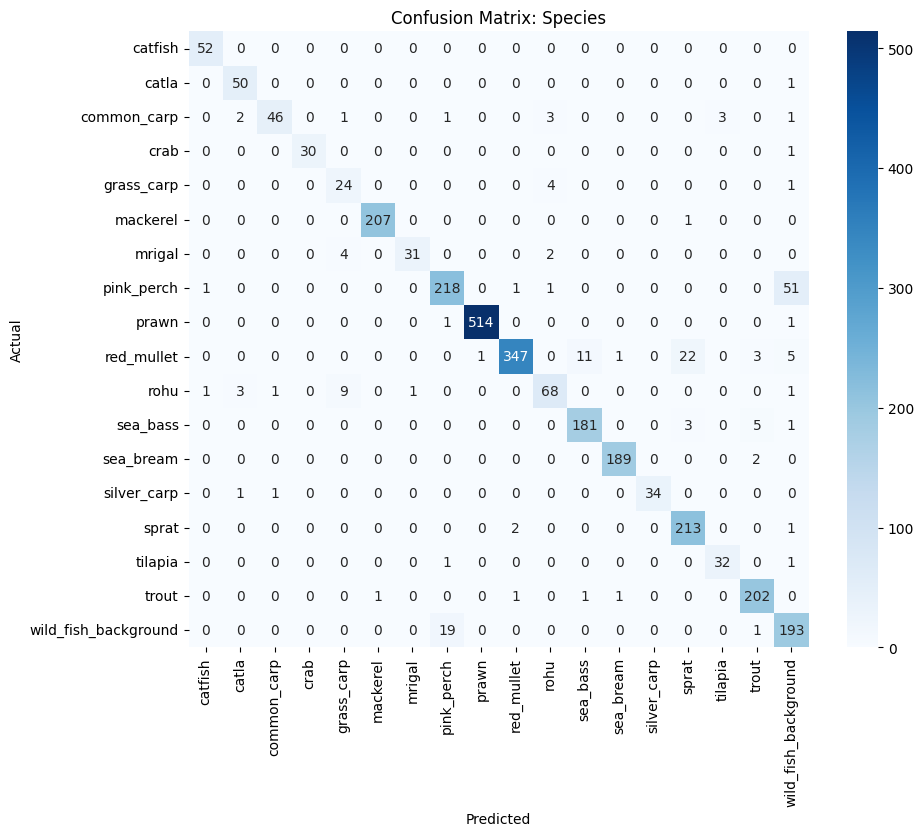


� GENERATING REPORT: DISEASE
✅ Loaded: fish_disease.weights.h5
   Running predictions...
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 235ms/step

                    precision    recall  f1-score   support

black_gill_disease       0.53      0.36      0.43        50
           healthy       0.64      0.92      0.76       100
  white_spot_virus       0.92      0.75      0.83       151

          accuracy                           0.74       301
         macro avg       0.70      0.68      0.67       301
      weighted avg       0.76      0.74      0.74       301



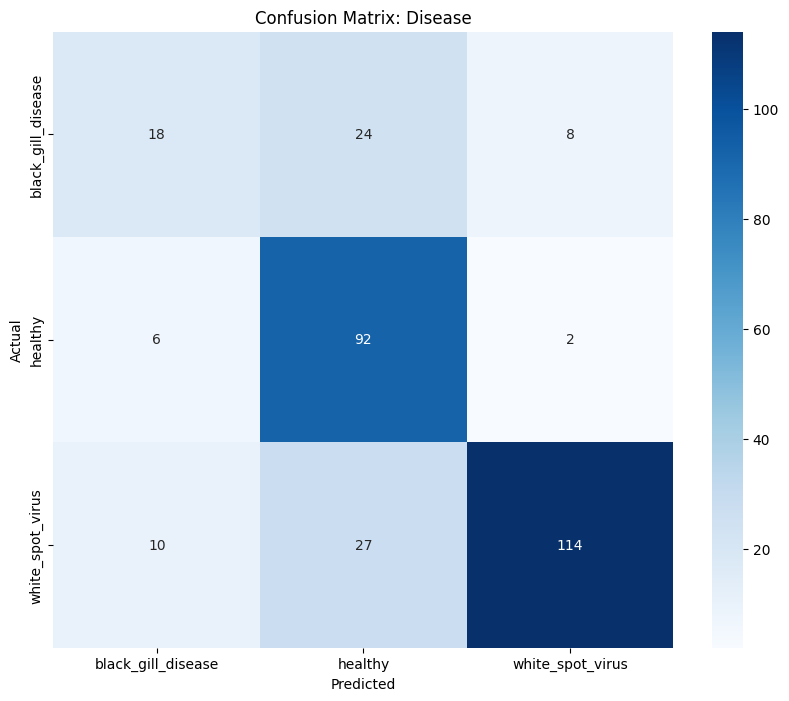

In [7]:
import tensorflow as tf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, models
from pathlib import Path

# ==========================================
# ⚙️ CONFIGURATION
# ==========================================
IMG_SIZE = 224
VAL_CSV = Path("/kaggle/working/processed/val_final.csv")
BATCH_SIZE = 32

# Class Maps
SPECIES_CLASSES = [
  'catfish', 'catla', 'common_carp', 'crab', 'grass_carp', 
  'mackerel', 'mrigal', 'pink_perch', 'prawn', 'red_mullet', 
  'rohu', 'sea_bass', 'sea_bream', 'silver_carp', 'sprat', 
  'tilapia', 'trout', 'wild_fish_background'
]
DISEASE_CLASSES = ['black_gill_disease', 'healthy', 'white_spot_virus']

# ==========================================
# 1. HELPERS
# ==========================================
def build_clean_model(num_classes):
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    base = tf.keras.applications.MobileNetV2(
        input_tensor=inputs,
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False, 
        weights=None
    )
    x = layers.GlobalAveragePooling2D()(base.output)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, out)

def get_val_dataset(df, target_col, classes):
    # Filter
    df_filtered = df[df[target_col].isin(classes)].copy()
    
    # Encode
    from sklearn.preprocessing import LabelEncoder
    encoder = LabelEncoder().fit(classes)
    labels = encoder.transform(df_filtered[target_col].values)
    paths = df_filtered['new_path'].values
    
    # Loader (No Augmentation)
    def load_val(path, label):
        img = tf.io.read_file(path)
        img = tf.io.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
        img = tf.cast(img, tf.float32) / 255.0
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_val, num_parallel_calls=tf.data.AUTOTUNE)
    # ⚠️ SHUFFLE=FALSE is critical for reports!
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE), labels

# ==========================================
# 2. EVALUATION ENGINE
# ==========================================
def evaluate_task(task_name, classes):
    print(f"\n� GENERATING REPORT: {task_name.upper()}")
    print("="*40)
    
    # 1. Load Data
    df_val = pd.read_csv(VAL_CSV)
    val_ds, y_true = get_val_dataset(df_val, f'{task_name}_label', classes)
    
    # 2. Load Model
    model = build_clean_model(len(classes))
    # Try multiple filename variations
    candidates = [
        f"fish_{task_name}.weights.h5", 
        f"fish_{task_name}_clean.weights.h5", 
        f"fish_{task_name}_weights.h5"
    ]
    weights_path = next((f for f in candidates if Path(f).exists()), None)
    
    if not weights_path:
        print(f"❌ Error: No weights found for {task_name}")
        return

    model.load_weights(weights_path)
    print(f"✅ Loaded: {weights_path}")
    
    # 3. Inference
    print("   Running predictions...")
    y_pred_probs = model.predict(val_ds, verbose=1)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # 4. Text Report
    print("\n" + classification_report(y_true, y_pred, target_names=classes))
    
    # 5. Confusion Matrix Heatmap
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix: {task_name.title()}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# ==========================================
# 3. RUN
# ==========================================
# Species Report
evaluate_task("species", SPECIES_CLASSES)

# Disease Report
evaluate_task("disease", DISEASE_CLASSES)

� CHECKING HEALTH: fish_species_model.tflite
   Input Shape: [  1 224 224   3]
   Input Dtype: <class 'numpy.float32'>
   Output Shape: [ 1 18]
   � Sample 1: True='prawn' -> Pred='prawn' (Conf: 0.91)
   � Sample 2: True='rohu' -> Pred='rohu' (Conf: 0.89)
   � Sample 3: True='sea_bass' -> Pred='sea_bass' (Conf: 0.96)


/usr/local/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


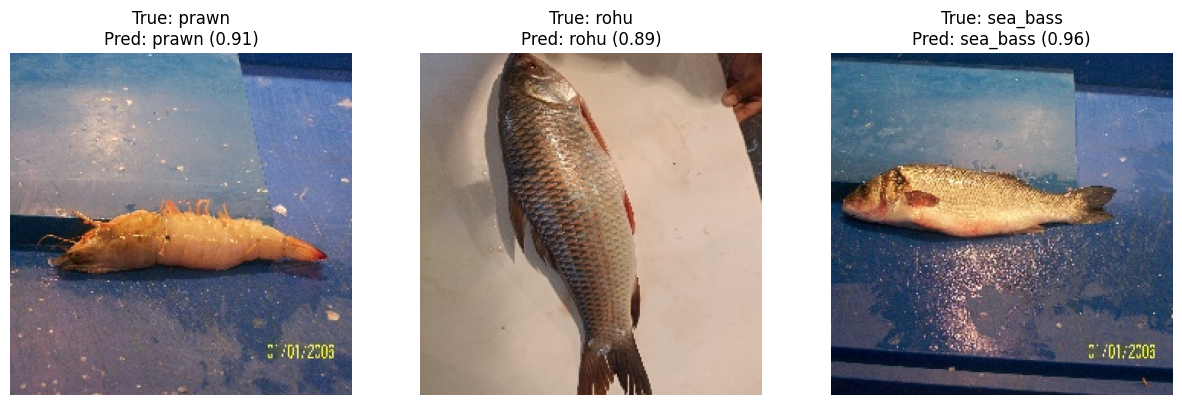

In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

# ==========================================
# ⚙️ CONFIG
# ==========================================
MODEL_PATH = "fish_species_model.tflite" # Check exact name!
VAL_CSV = Path("/kaggle/working/processed/val_final.csv")
IMG_SIZE = 224

SPECIES_CLASSES = [
  'catfish', 'catla', 'common_carp', 'crab', 'grass_carp', 
  'mackerel', 'mrigal', 'pink_perch', 'prawn', 'red_mullet', 
  'rohu', 'sea_bass', 'sea_bream', 'silver_carp', 'sprat', 
  'tilapia', 'trout', 'wild_fish_background'
]

def check_tflite_health():
    print(f"� CHECKING HEALTH: {MODEL_PATH}")
    
    if not Path(MODEL_PATH).exists():
        print("❌ ERROR: File not found!")
        return

    # 1. Load Interpreter
    interpreter = tf.lite.Interpreter(model_path=MODEL_PATH)
    interpreter.allocate_tensors()
    
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]
    
    print(f"   Input Shape: {input_details['shape']}")
    print(f"   Input Dtype: {input_details['dtype']}")
    print(f"   Output Shape: {output_details['shape']}")
    
    # 2. Grab 3 Test Fish (Different Classes)
    df = pd.read_csv(VAL_CSV)
    test_samples = []
    
    # Try to grab a Prawn, a Rohu, and a Sea Bass
    for target in ['prawn', 'rohu', 'sea_bass']:
        row = df[df['species_label'] == target].iloc[0]
        test_samples.append((row['new_path'], target))
        
    # 3. Run Inference
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for i, (path, true_label) in enumerate(test_samples):
        # A. Manual Preprocessing (Exactly what React should do)
        img = Image.open(path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        input_data = np.array(img, dtype=np.float32)
        input_data = input_data / 255.0 # Normalize 0-1
        input_data = np.expand_dims(input_data, axis=0) # Add batch dim
        
        # B. Inject into Model
        interpreter.set_tensor(input_details['index'], input_data)
        interpreter.invoke()
        output_data = interpreter.get_tensor(output_details['index'])[0]
        
        # C. Decode
        pred_idx = np.argmax(output_data)
        pred_label = SPECIES_CLASSES[pred_idx]
        confidence = output_data[pred_idx]
        
        # D. Visualize
        axes[i].imshow(img)
        axes[i].set_title(f"True: {true_label}\nPred: {pred_label} ({confidence:.2f})")
        axes[i].axis('off')
        
        print(f"   � Sample {i+1}: True='{true_label}' -> Pred='{pred_label}' (Conf: {confidence:.2f})")
        
        # CHECK FOR BIAS
        if pred_label == 'prawn' and true_label != 'prawn':
            print("      ⚠️ ERROR: False Prawn Detection!")

    plt.show()

check_tflite_health()

In [ ]:
!pip uninstall -y tensorflow
!pip install "numpy<1.24" "protobuf==3.20.3" "tensorflow==2.12.0" --force-reinstall
print("✅ Downgraded. PLEASE RESTART SESSION NOW.")

In [ ]:
import tensorflow as tf
print(f"� TensorFlow: {tf.__version__}")

In [ ]:
# install converter if not already present
!pip install -q tensorflowjs
# convert from Keras .h5 to TFJS format
# tensorflowjs_converter --input_format=keras fish_species_v1.h5 web_models/fish_species
# tensorflowjs_converter --input_format=keras fish_disease_v1.h5 web_models/fish_disease

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

print(f"� Exporting on TF Version: {tf.__version__}") # Must be 2.12.0

# --- ARCHITECTURE BUILDERS ---
# Must match your training architecture exactly
def build_species_model():
    base = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights=None)
    x = layers.GlobalAveragePooling2D()(base.output)
    # Note: Dropout is inactive in inference
    out = layers.Dense(18, activation='softmax', name='species')(x)
    return models.Model(base.input, out)

def build_disease_model():
    base = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights=None)
    x = layers.GlobalAveragePooling2D()(base.output)
    out = layers.Dense(3, activation='softmax', name='disease')(x)
    return models.Model(base.input, out)

# --- THE NUCLEAR CONVERTER ---
def nuke_and_export(model_builder, weights_path, output_tflite):
    print(f"\n☢️ Processing {output_tflite}...")
    
    # 1. Build & Load
    model = model_builder()
    try:
        # Load raw weights (bypass Keras config issues)
        # If you have .h5, use load_weights. If .npy, use set_weights.
        model.load_weights(weights_path)
        print("   ✅ Weights Loaded.")
    except Exception as e:
        print(f"   ❌ Load Failed: {e}")
        return

    # 2. CONCRETE FUNCTION (The Freeze)
    run_model = tf.function(lambda x: model(x))
    concrete_func = run_model.get_concrete_function(
        tf.TensorSpec([1, 224, 224, 3], tf.float32)
    )

    # 3. CONVERT (Pure TFLite Mode)
    converter = tf.lite.TFLiteConverter.from_concrete_functions([concrete_func])
    
    # �️ The "Old Logic" Flags
    converter.optimizations = [tf.lite.Optimize.DEFAULT] # Dynamic Range
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS] # <--- NO SELECT OPS
    converter.experimental_enable_resource_variables = False
    
    tflite_model = converter.convert()

    # 4. SAVE
    with open(output_tflite, 'wb') as f:
        f.write(tflite_model)
    
    print(f"   � Saved: {output_tflite} ({len(tflite_model)/1024/1024:.2f} MB)")

# --- EXECUTE ---
# Ensure these filenames match your saved weights
nuke_and_export(build_species_model, "fish_species_v1.h5", "fish_species_model.tflite")
nuke_and_export(build_disease_model, "fish_disease_v1.h5", "fish_disease_model.tflite")

In [ ]:
import tensorflow as tf

# --- CONFIGURATION ---
# Replace with the exact name of the file you want to check
MODEL_FILE = "fish_species_folded.tflite" 

def inspect_tflite(model_path):
    print(f"�️ Inspecting: {model_path}...\n")
    
    # 1. Load the TFLite model
    try:
        with open(model_path, 'rb') as f:
            model_content = f.read()
    except FileNotFoundError:
        print("❌ Error: File not found!")
        return

    # 2. Use the Analyzer (Official Tool)
    # This prints a report of every operation inside the graph
    # We capture it to a string so we can search it
    try:
        analysis = tf.lite.experimental.Analyzer.analyze(model_content=model_content)
    except Exception as e:
        print(f"⚠️ Analyzer failed (might be old TF version): {e}")
        # Fallback method: Interpreter inspection
        interpreter = tf.lite.Interpreter(model_path=model_path)
        print("✅ Interpreter loaded successfully (File is valid TFLite).")
        return

    # 3. The "Contamination" Check
    # We look for specific keywords that indicate "Stateful Variables"
    forbidden_ops = ['ReadVariable', 'AssignVariable', 'VarHandle', 'Resource']
    found_bad_ops = []
    
    print("\n--- � SCANNING FOR ZOMBIE VARIABLES ---")
    # The analyzer output prints ops like "  Op#0 CONV_2D..."
    # We simulate scanning (since Analyzer prints directly to stdout in most versions)
    # But visually, look for these in the output below!
    
    print(f"� CHECK THE OUTPUT ABOVE FOR: {forbidden_ops}")
    print("   If you see them, the model is NOT frozen.")
    print("   If you only see 'CONV_2D', 'DEPTHWISE_CONV_2D', 'ADD', 'RESHAPE', etc., you are SAFE.")

# Run it
inspect_tflite(MODEL_FILE)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from pathlib import Path

# --- CONFIGURATION ---
TRAIN_CSV = "/kaggle/working/processed/train_final.csv"
EXPORT_DIR = Path("/kaggle/working/exported_models")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print("⏳ Extracting Label Maps...")
train_df = pd.read_csv(TRAIN_CSV)

# 1. RE-BUILD SPECIES ENCODER (Robust)
# Filter out 'unknown' species labels
sp_subset = train_df[train_df['species_label'] != 'unknown']
sp_labels = sp_subset['species_label'].unique()
# Ensure background is included if missing from train set (safety)
if 'wild_fish_background' not in sp_labels:
    sp_labels = np.append(sp_labels, 'wild_fish_background')
sp_list = np.sort(sp_labels)
sp_encoder = LabelEncoder()
sp_encoder.fit(sp_list)

# 2. RE-BUILD DISEASE ENCODER (Robust)
# Filter out 'unknown' and 'healthy' if you only want specific diseases, 
# BUT usually 'healthy' is a valid class 1.
dz_subset = train_df[train_df['disease_label'] != 'unknown']
dz_labels = dz_subset['disease_label'].unique()
dz_list = np.sort(dz_labels)
dz_encoder = LabelEncoder()
dz_encoder.fit(dz_list)

# 3. SAVE TO TEXT FILES
def save_labels(filename, classes):
    path = EXPORT_DIR / filename
    with open(path, "w") as f:
        for label in classes:
            f.write(f"{label}\n")
    print(f"✅ Saved {filename} ({len(classes)} classes)")

save_labels("labels_species.txt", sp_encoder.classes_)
save_labels("labels_disease.txt", dz_encoder.classes_)

print("\n📦 DOWNLOAD THESE FILES:")
print(f"Species 0 -> {sp_encoder.classes_[0]}")
if len(dz_encoder.classes_) > 0:
    print(f"Disease 0 -> {dz_encoder.classes_[0]}")
else:
    print("⚠️ Warning: No disease classes found. Check train_final.csv 'disease_label' column.")

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from pathlib import Path

# --- 1. CONFIGURATION ---
IMG_SIZE = 224
BATCH_SIZE = 32
VAL_CSV = Path("/kaggle/working/processed/val_final.csv")

# Exact Classes (Must match Training)
SPECIES_CLASSES = [
  'catfish', 'catla', 'common_carp', 'crab', 'grass_carp', 
  'mackerel', 'mrigal', 'pink_perch', 'prawn', 'red_mullet', 
  'rohu', 'sea_bass', 'sea_bream', 'silver_carp', 'sprat', 
  'tilapia', 'trout', 'wild_fish_background'
]
DISEASE_CLASSES = ['black_gill_disease', 'healthy', 'white_spot_virus']

# --- 2. DATA LOADING ---
print("� Loading Validation Data...")
val_df = pd.read_csv(VAL_CSV)

# --- 3. EVALUATION PIPELINE GENERATOR ---
def create_eval_dataset(df, target_col, classes):
    # Filter for target classes
    df_filtered = df[df[target_col].isin(classes)].copy()
    paths = df_filtered['new_path'].values
    
    # Encode
    encoder = LabelEncoder()
    encoder.fit(classes)
    labels = encoder.transform(df_filtered[target_col].values)
    
    # Create DS (No Shuffle!)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def load(path, label):
        img = tf.io.read_file(path)
        img = tf.io.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
        img = tf.cast(img, tf.float32) / 255.0 
        return img, label
        
    # Batch & Prefetch (But keep order)
    return ds.map(load).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE), labels, encoder

# ==========================================
# � REPORT A: SPECIES
# ==========================================
print("\n� TESTING SPECIES MODEL...")
eval_ds_sp, y_true_sp, sp_encoder = create_eval_dataset(val_df, 'species_label', SPECIES_CLASSES)

try:
    model_sp = tf.keras.models.load_model("fish_species_v1.h5")
    print("✅ Model Loaded. Predicting...")
    
    y_pred_raw_sp = model_sp.predict(eval_ds_sp, verbose=1)
    y_pred_sp = np.argmax(y_pred_raw_sp, axis=1)
    
    print("\n" + "="*40)
    print("� SPECIES CLASSIFICATION REPORT")
    print("="*40)
    print(classification_report(y_true_sp, y_pred_sp, target_names=sp_encoder.classes_))
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(confusion_matrix(y_true_sp, y_pred_sp), annot=True, fmt='d', cmap='Blues',
                xticklabels=sp_encoder.classes_, yticklabels=sp_encoder.classes_)
    plt.title('Species Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.xticks(rotation=90)
    plt.show()

except Exception as e:
    print(f"❌ Species Eval Failed: {e}")

# ==========================================
# � REPORT B: DISEASE
# ==========================================
print("\n� TESTING DISEASE MODEL...")
eval_ds_dz, y_true_dz, dz_encoder = create_eval_dataset(val_df, 'disease_label', DISEASE_CLASSES)

try:
    model_dz = tf.keras.models.load_model("fish_disease_v1.h5")
    print("✅ Model Loaded. Predicting...")
    
    y_pred_raw_dz = model_dz.predict(eval_ds_dz, verbose=1)
    y_pred_dz = np.argmax(y_pred_raw_dz, axis=1)
    
    print("\n" + "="*40)
    print("� DISEASE CLASSIFICATION REPORT")
    print("="*40)
    print(classification_report(y_true_dz, y_pred_dz, target_names=dz_encoder.classes_))
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(confusion_matrix(y_true_dz, y_pred_dz), annot=True, fmt='d', cmap='Reds',
                xticklabels=dz_encoder.classes_, yticklabels=dz_encoder.classes_)
    plt.title('Disease Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

except Exception as e:
    print(f"❌ Disease Eval Failed: {e}")

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

# --- CONFIGURATION ---
# Ensure this matches your saved weights filename
WEIGHTS_PATH = "fishnet_v6_robust.weights.h5" 
OUTPUT_FILE = "fishnet_final_v4_nuclear.tflite" # Overwrite the slow one

print(f"⚡ Speeding up model on TF Version: {tf.__version__}") 

# 1. REBUILD EXACT ARCHITECTURE (18 Classes)
def build_model():
    IMG_SIZE = 224
    NUM_SPECIES = 18
    NUM_DISEASES = 3
    
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='input_1')
    # Base (ImageNet weights are fine as placeholders, we overwrite them)
    base = tf.keras.applications.MobileNetV2(input_tensor=inputs, include_top=False, weights=None)
    
    x = layers.GlobalAveragePooling2D()(base.output)
    # Skip dropout for inference structure
    
    # Heads
    s = layers.Dense(128, activation='relu')(x)
    out_s = layers.Dense(NUM_SPECIES, activation='softmax', name='species')(s)
    
    f = layers.Dense(64, activation='relu')(x)
    out_f = layers.Dense(1, activation='sigmoid', name='freshness')(f)
    
    d = layers.Dense(64, activation='relu')(x)
    out_d = layers.Dense(NUM_DISEASES, activation='softmax', name='disease')(d)
    
    return models.Model(inputs=inputs, outputs=[out_s, out_f, out_d])

model = build_model()

# 2. LOAD WEIGHTS
print("� Injecting Weights...")
try:
    model.load_weights(WEIGHTS_PATH)
    print("✅ Weights Loaded.")
except Exception as e:
    print(f"❌ Weight Load Failed: {e}")
    raise e

# 3. QUANTIZE & CONVERT
print("� Freezing & Quantizing (Making it FAST)...")

# Use Concrete Function to guarantee "Stateless" execution (Fixes READ_VARIABLE)
run_model = tf.function(lambda x: model(x))
concrete_func = run_model.get_concrete_function(
    tf.TensorSpec([1, 224, 224, 3], tf.float32)
)

converter = tf.lite.TFLiteConverter.from_concrete_functions([concrete_func])

# � SPEED FLAGS �
converter.optimizations = [tf.lite.Optimize.DEFAULT] # <--- THIS IS THE KEY
converter.experimental_enable_resource_variables = False
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS, tf.lite.OpsSet.SELECT_TF_OPS]

tflite_model = converter.convert()

# 4. SAVE
with open(OUTPUT_FILE, 'wb') as f:
    f.write(tflite_model)

print(f"� DONE. Download '{OUTPUT_FILE}'")
print(f"� New Size: {len(tflite_model)/1024/1024:.2f} MB (Should be ~5 MB)")

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# --- CONFIGURATION ---
MODEL_PATH = "fishnet_v4_gpu.h5"
TRAIN_CSV = "/kaggle/working/processed/train_final.csv"
VAL_CSV = "/kaggle/working/processed/val_final.csv"

print("⏳ initializing Truth Serum...")

# 1. Load Data & Encoders (Standard)
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)

# Species Encoder
sp_subset = train_df[train_df['type'].isin(['species', 'dual'])]
sp_labels = sp_subset[sp_subset['species_label'] != 'unknown']['species_label'].unique()
sp_list = np.sort(np.unique(np.append(sp_labels, 'wild_fish_background')))
sp_encoder = LabelEncoder()
sp_encoder.fit(sp_list)
SPECIES_CLASSES = sp_encoder.classes_

# 2. Load Model
custom_objects = {
    "masked_sparse_categorical": lambda y, p: 0.0, 
    "masked_mse": lambda y, p: 0.0,
    "sparse_categorical_focal_loss": lambda g, a: (lambda y, p: 0.0),
    "focal_loss_fixed": lambda y, p: 0.0,
    "Cast": tf.keras.layers.Layer
}
model = tf.keras.models.load_model(MODEL_PATH, custom_objects=custom_objects, compile=False)

# 3. PICK A TARGET (A known species)
target_species = 'rohu' # Let's test a Rohu
sample = val_df[val_df['species_label'] == target_species].sample(1).iloc[0]

print(f"\n📸 TESTING IMAGE: {sample['new_path']}")
print(f"🏷️ TRUE LABEL: {sample['species_label']}")

# 4. MANUAL PREDICTION
img = cv2.imread(sample['new_path'])
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img, (224, 224))
# 🚨 SANITY CHECK: Are we normalizing correctly?
input_tensor = np.expand_dims(img_resized.astype(np.float32) / 255.0, axis=0)

preds = model.predict(input_tensor, verbose=0)
species_probs = preds[0][0]

# 5. THE REVEAL
top_3_indices = np.argsort(species_probs)[-3:][::-1]

print("\n🤖 MODEL PREDICTIONS:")
for idx in top_3_indices:
    
    # Map index to class name using our current encoder
    class_name = SPECIES_CLASSES[idx]
    confidence = species_probs[idx]
    print(f"   #{idx}: {class_name} ({confidence:.2%})")

plt.imshow(img_rgb)
plt.title(f"True: {target_species}")
plt.axis('off')
plt.show()

In [ ]:
import os
import pandas as pd
from pathlib import Path
from collections import Counter

# --- CONFIGURATION ---
ROOT_DIR = Path("/kaggle/input")

# 1. DEFINE YOUR CURRENT "KNOWN" LIST
# These are the keywords your Notebook 01 is ALREADY catching.
# We want to find what is NOT on this list.
CURRENT_MAP_KEYS = [
    'rohu', 'catla', 'mrigal', 'tilapia', 'catfish', 'pangasius', 
    'silver', 'common', 'grass', 'hilsa', 'mackerel', 'pomfret', 
    'seer', 'barracuda', 'sardine', 'anchovy', 'snapper', 'grouper', 
    'trevally', 'tuna', 'salmon', 'cod', 'mahi', 'prawn', 'shrimp', 
    'crab', 'healthy', 'white_spot', 'black_gill', 'fresh'
]

print("🕵️ Starting Census of the 'Wild Background'...")

# 2. FIND FISHNET
fishnet_roots = list(ROOT_DIR.glob("**/*fishnet*"))
if not fishnet_roots:
    print("❌ FishNet not found!")
else:
    search_root = fishnet_roots[0]
    print(f"📂 Scanning: {search_root}")
    
    # 3. COUNT THE IGNORED FOLDERS
    ignored_counts = Counter()
    
    # Walk through all folders
    for p in search_root.rglob("*"):
        if p.is_dir():
            folder_name = p.name.lower()
            
            # Check if this folder is already being caught
            is_caught = False
            for key in CURRENT_MAP_KEYS:
                if key in folder_name:
                    is_caught = True
                    break
            
            # If NOT caught, count the images inside
            if not is_caught:
                n_images = len(list(p.glob("*.jpg"))) + len(list(p.glob("*.png")))
                if n_images > 0:
                    # Use the folder name (Family) as the key
                    ignored_counts[folder_name] += n_images

    # 4. SHOW THE TOP CANDIDATES
    print("\n--- 🏆 TOP 20 'HIDDEN' FAMILIES ---")
    print(f"{'FAMILY NAME':<25} | {'IMAGE COUNT'}")
    print("-" * 40)
    
    for family, count in ignored_counts.most_common(40):
        print(f"{family:<25} | {count}")

    print("\n💡 ACTION: Pick the top 5-10 from this list to add to your LABEL_MAP.")

In [ ]:
import os
import cv2
import numpy as np
import shutil
from pathlib import Path
from tqdm.notebook import tqdm
import yaml

# --- CONFIGURATION ---
# Adjust this to match exactly where the dataset is in your Kaggle Input
INPUT_ROOT = Path("/kaggle/input/fish-recognition-ground-truth-data") 
IMAGES_DIR = INPUT_ROOT / "fish_image" / "fish_image" 
MASKS_DIR = INPUT_ROOT / "mask_image" / "mask_image"

# Output for YOLO
OUTPUT_DIR = Path("/kaggle/working/yolo_dataset")
IMG_OUT = OUTPUT_DIR / "images" / "train"
LBL_OUT = OUTPUT_DIR / "labels" / "train"

# Create Directories
IMG_OUT.mkdir(parents=True, exist_ok=True)
LBL_OUT.mkdir(parents=True, exist_ok=True)

print("� Starting Mask -> Box Conversion...")

valid_files = list(IMAGES_DIR.glob("*.png")) + list(IMAGES_DIR.glob("*.jpg"))
print(f"� Found {len(valid_files)} images.")

count = 0
for img_path in tqdm(valid_files):
    # 1. Find Matching Mask
    mask_name = img_path.name # Assuming mask has same name
    mask_path = MASKS_DIR / mask_name
    
    if not mask_path.exists():
        # Try changing extension if mismatch (e.g. image.jpg vs mask.png)
        mask_path = MASKS_DIR / (img_path.stem + ".png")
        if not mask_path.exists():
            continue # Skip if no mask
            
    # 2. Read Mask
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None: continue

    # 3. Find Contours (The Fish Shape)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # 4. Convert to YOLO Format (class x_center y_center width height)
    # We assume class '0' is 'fish'
    height, width = mask.shape
    boxes = []
    
    for cnt in contours:
        if cv2.contourArea(cnt) < 1000: continue # Ignore tiny noise
        
        x, y, w, h = cv2.boundingRect(cnt)
        
        # Normalize 0-1
        x_center = (x + w/2) / width
        y_center = (y + h/2) / height
        w_norm = w / width
        h_norm = h / height
        
        boxes.append(f"0 {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}")
        
    if boxes:
        # Copy Image
        shutil.copy(img_path, IMG_OUT / img_path.name)
        
        # Save Label
        txt_path = LBL_OUT / (img_path.stem + ".txt")
        with open(txt_path, "w") as f:
            f.write("\n".join(boxes))
        
        count += 1

print(f"✅ Converted {count} images successfully.")

# --- CREATE DATA.YAML ---
data_yaml = {
    'path': str(OUTPUT_DIR.absolute()),
    'train': 'images/train',
    'val': 'images/train', # Use train as val for simple hackathon demo
    'nc': 1,
    'names': ['fish']
}

with open(OUTPUT_DIR / "data.yaml", 'w') as f:
    yaml.dump(data_yaml, f)

print("✅ dataset.yaml created.")

In [ ]:
from ultralytics import YOLO

# 1. Load Nano Model (Fastest)
model = YOLO('yolov8n.pt') 

# 2. Train
print(" Starting Training on Ground Truth Data...")
results = model.train(
    data="/kaggle/working/yolo_dataset/data.yaml",
    epochs=15,
    imgsz=320,
    batch=16,
    name='fish_detector_v2',
    project='/kaggle/working/runs'
)

# 3. Export to TFLite (Int8)
print(" Exporting...")
model.export(format='tflite', imgsz=320, int8=True)

print("� Download: /kaggle/working/runs/fish_detector_v2/weights/best_saved_model/best_int8.tflite")

In [ ]:
from ultralytics import YOLO
import glob
import random
from pathlib import Path
import matplotlib.pyplot as plt
import cv2

# --- CONFIGURATION ---
# 1. Find the TFLite model
possible_models = list(Path("/kaggle/working/runs").rglob("*.tflite"))
if not possible_models:
    if Path("/kaggle/working/fish_detector_v1.tflite").exists():
        MODEL_PATH = Path("/kaggle/working/fish_detector_v1.tflite")
    else:
        raise FileNotFoundError("❌ No TFLite model found!")
else:
    MODEL_PATH = possible_models[-1]

print(f"✅ Loaded Detector: {MODEL_PATH.name}")

# 2. Find Images
search_patterns = [
    "/kaggle/input/**/valid/**/*.jpg",
    "/kaggle/input/**/test/**/*.jpg",
    "/kaggle/input/**/*.jpg" 
]

image_pool = []
for pattern in search_patterns:
    found = list(glob.glob(pattern, recursive=True))
    # Filter for likely real images
    image_pool.extend([f for f in found if "rf" in f or "images" in f]) 
    if len(image_pool) > 50: break 

if len(image_pool) < 10:
    samples = image_pool
else:
    samples = random.sample(image_pool, 10)

print(f"📸 Selected {len(samples)} random images.")

# --- 3. RUN INFERENCE (SEQUENTIAL FIX) ---
print("🧠 Running TFLite Inference...")
model = YOLO(str(MODEL_PATH))

results = []
# 🚨 FIX: Process one by one because TFLite is Batch=1
for img_path in samples:
    # Run on single image
    res = model.predict(img_path, imgsz=320, conf=0.25, verbose=False)
    results.append(res[0]) 

# --- 4. VISUALIZE GRID ---
rows = 5
cols = 2
fig, axes = plt.subplots(rows, cols, figsize=(15, 20))
fig.suptitle(f'Fish Detector Audit: {MODEL_PATH.name}', fontsize=16)

for i, result in enumerate(results):
    if i >= rows * cols: break
    ax = axes.flat[i]
    
    # Plot
    plotted_img = result.plot(line_width=2, font_size=12)
    rgb_img = cv2.cvtColor(plotted_img, cv2.COLOR_BGR2RGB)
    
    ax.imshow(rgb_img)
    ax.axis('off')
    
    count = len(result.boxes)
    filename = Path(result.path).name
    ax.set_title(f"{filename}\nDetected: {count}", color='green' if count > 0 else 'red')

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

# --- CONFIGURATION ---
MODEL_PATH = "fishnet_V6_best.h5"
TRAIN_CSV = "/kaggle/working/processed/train_final.csv"
VAL_CSV = "/kaggle/working/processed/val_final.csv"

print("⏳ Loading Forensic Tools...")

# 1. RE-BUILD ENCODERS (Crucial for correct labels)
train_df = pd.read_csv(TRAIN_CSV)

# Species Encoder
sp_list = np.sort(train_df[train_df['type'] == 'species']['label'].unique())
sp_list = np.unique(np.append(sp_list, 'wild_fish_background'))
sp_encoder = LabelEncoder()
sp_encoder.fit(sp_list)
SPECIES_CLASSES = sp_encoder.classes_

# Load Model
custom_objects = {
    "masked_sparse_categorical": lambda y, p: 0.0, 
    "masked_mse": lambda y, p: 0.0,
    "sparse_categorical_focal_loss": lambda gamma, alpha: (lambda y, p: 0.0),
    "focal_loss_fixed": lambda y, p: 0.0,
    "Cast": tf.keras.layers.Layer
}
model = tf.keras.models.load_model(MODEL_PATH, custom_objects=custom_objects, compile=False)

# Helper: Preprocessing
def preprocess_batch(paths):
    images = []
    for p in paths:
        img = tf.io.read_file(p)
        img = tf.io.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, (224, 224))
        img = tf.cast(img, tf.float32) / 255.0
        images.append(img)
    return np.array(images)

# ==========================================
# 🕵️ REPORT 1: SPECIES HEAD FORENSICS (FIXED)
# ==========================================
print("\n🐟 GENERATING SPECIES REPORT...")
val_df = pd.read_csv(VAL_CSV)

# 🚨 FIX: Include 'dual' so we catch Prawns too!
species_df = val_df[val_df['type'].isin(['species', 'dual'])].copy()

if len(species_df) > 0:
    # Prepare Data
    paths = species_df['new_path'].values
    
    # Filter out 'unknown' species (like eyes/gills) just in case
    valid_mask = species_df['species_label'].isin(SPECIES_CLASSES)
    paths = paths[valid_mask]
    true_labels_str = species_df.loc[valid_mask, 'species_label'].values
    true_labels_idx = sp_encoder.transform(true_labels_str)
    
    # Predict
    print(f"   Processing {len(paths)} species images...")
    batch_size = 32
    preds_idx = []
    
    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i+batch_size]
        batch_imgs = preprocess_batch(batch_paths)
        # Safety: verbose=0 to prevent progress bar crashes on small batches
        batch_preds = model.predict(batch_imgs, verbose=0) 
        preds_idx.extend(np.argmax(batch_preds[0], axis=1))
        
    # Plot CM
    cm = confusion_matrix(true_labels_idx, preds_idx)
    plt.figure(figsize=(14, 12)) # Made it bigger for more species
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=SPECIES_CLASSES, yticklabels=SPECIES_CLASSES)
    plt.title('Species Head Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.xticks(rotation=45, ha='right')
    plt.show()
    
    print("📋 SPECIES CLASSIFICATION REPORT:")
    print(classification_report(true_labels_idx, preds_idx, target_names=SPECIES_CLASSES, zero_division=0))
else:
    print("⚠️ No Species validation data found!")

# ==========================================
# �️ REPORT 2: FRESHNESS HEAD FORENSICS (Fixed)
# ==========================================
print("\n� GENERATING FRESHNESS REPORT...")
freshness_df = val_df[val_df['type'] == 'freshness'].copy()

if len(freshness_df) > 0:
    paths = freshness_df['new_path'].values
    true_scores = freshness_df['freshness_score'].values
    true_binary = (true_scores > 0.5).astype(int)
    
    print(f"   Processing {len(freshness_df)} freshness images...")
    pred_scores = []
    
    # Batch processing
    batch_size = 32
    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i+batch_size]
        batch_imgs = preprocess_batch(batch_paths)
        batch_preds = model.predict(batch_imgs, verbose=0)
        pred_scores.extend(batch_preds[1].flatten())
        
    pred_binary = (np.array(pred_scores) > 0.5).astype(int)
    
    # Plot CM
    class_names = ['Stale', 'Fresh']
    # FIX: Explicitly pass labels=[0, 1] to handle cases where one class is missing
    cm_fresh = confusion_matrix(true_binary, pred_binary, labels=[0, 1])
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_fresh, annot=True, fmt='d', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Freshness Head Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()
    
    print("� FRESHNESS CLASSIFICATION REPORT:")
    # FIX: Force the report to acknowledge both classes even if one is missing
    print(classification_report(true_binary, pred_binary, labels=[0, 1], target_names=class_names, zero_division=0))
    
    # Scatter Plot
    plt.figure(figsize=(8, 4))
    plt.scatter(true_scores, pred_scores, alpha=0.5, color='purple')
    plt.xlabel("Actual Score (0=Stale, 1=Fresh)")
    plt.ylabel("Predicted Score")
    plt.title("Freshness Regression Analysis")
    plt.grid(True, linestyle='--')
    plt.plot([0, 1], [0, 1], 'r--') 
    plt.show()
    
else:
    print("⚠️ No Freshness validation data found!")